# Eksperimen Normalisasi RMSNorm pada FFNN

Notebook ini melakukan eksperimen untuk membandingkan model FFNN tanpa normalisasi dan dengan normalisasi RMSNorm. Eksperimen meliputi pelatihan, perbandingan prediksi akhir, grafik loss, serta distribusi bobot dan gradien.

In [119]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os 

# Setup path untuk import dari src folder
loc = os.getcwd()
root = os.path.dirname(loc)
srcPath = os.path.join(root, "src")
sys.path.insert(0, srcPath)

from ffnn.model import FFNN
from ffnn.utils.activation_function import Linear, ReLU, Sigmoid, Tanh
from ffnn.utils.loss_function import MSE, BinaryCrossEntropy, CategoricalCrossEntropy
from ffnn.utils.initialization import ZeroInit, UniformInit, NormalInit, XavierInit, HeInit
from ffnn.utils.regularizer import L1, L2
from ffnn.utils.normalizer import RMSNorm
from ffnn.plot import plotTrainingHistory, plotWeightDistribution, plotGradientDistribution

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neural_network import MLPClassifier

plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)

In [120]:
# Reload modules jika perlu
import importlib

In [121]:
# Load and Preprocess Dataset
# ambil dari pickle  
import pickle 
import os
loc = os.getcwd()
models  = os.path.join(loc, 'models')
with open(os.path.join(models, 'processedData.pkl'), 'rb') as f:  
    data = pickle.load(f)

print(data)

Xtr = data['X_train']
Xte = data['X_test']
ytr = data['y_train']
yte = data['y_test']

if (Xtr is not None) and (Xte is not None) and (ytr is not None) and (yte is not None):
    print(f'Xtr shape: {Xtr.shape}')
    print(f'Xte shape: {Xte.shape}')
    print(f'ytr shape: {ytr.shape}')
    print(f'yte shape: {yte.shape}')

# Config
Xtr = Xtr.values if hasattr(Xtr, 'values') else Xtr
Xte = Xte.values if hasattr(Xte, 'values') else Xte
ytr = ytr.values.reshape(-1, 1) if hasattr(ytr, 'values') else ytr
yte = yte.values.reshape(-1, 1) if hasattr(yte, 'values') else yte

print(f'After conversion:')
print(f'Xtr type: {type(Xtr)}, shape: {Xtr.shape}')
print(f'Xte type: {type(Xte)}, shape: {Xte.shape}')
print(f'ytr type: {type(ytr)}, shape: {ytr.shape}')
print(f'yte type: {type(yte)}, shape: {yte.shape}')

# Split Xtr menjadi train dan val
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(Xtr, ytr, test_size=0.2, random_state=42, stratify=ytr)
X_test, y_test = Xte, yte

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape:", X_test.shape)

{'X_train':           cgpa  backlogs  internship_count  aptitude_score  \
1575  0.385195 -1.099921          1.745749        1.854680   
786   0.686205  0.679576          0.717950        0.809427   
4348 -0.045942  0.679576          1.745749       -1.609019   
8411 -0.437796  1.569325          1.745749       -0.653170   
8650 -0.396835 -0.210172         -1.337648       -0.690039   
...        ...       ...               ...             ...   
6526 -0.302160 -0.210172          0.717950       -1.134934   
922   0.545952  0.679576         -0.309849       -1.043985   
4705 -0.260639 -1.099921         -0.309849        0.218275   
3572 -2.264060  0.679576         -0.309849       -0.972783   
6512 -2.169449 -0.210172          0.717950       -1.186435   

      communication_score  internship_quality_score  college_tier_Tier 1  \
1575            -0.596811                  0.840215                  0.0   
786              1.099136                  1.591018                  0.0   
4348           

/home/stahlynx/Coding/Semester-6/feed-forward-neural-network/venv/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Model Tanpa Normalisasi

In [122]:
# Define Model Without Normalization
layer_sizes = [X_train.shape[1], 64, 32, 1]
activations = [ReLU(), ReLU(), Sigmoid()]
loss_fn = BinaryCrossEntropy()
initializer = NormalInit()
regularizer = L1(0.001)

model_no_norm = FFNN(layer_sizes, activations, loss_fn, initializer, regularizer, None)

In [123]:
# Train Model Without Normalization
history_no_norm = model_no_norm.fit(
    X_train, y_train,
    X_val=X_val, y_val=y_val,
    epochs=50,
    lr=0.01,
    batch_size=32,
    verbose=1
)

Epoch 1/50 - train_loss: 6.646526 - val_loss: 4.940191


Epoch 2/50 - train_loss: 4.528351 - val_loss: 3.687534
Epoch 3/50 - train_loss: 3.024805 - val_loss: 2.280343
Epoch 4/50 - train_loss: 1.706937 - val_loss: 1.250682
Epoch 5/50 - train_loss: 1.189828 - val_loss: 0.844629
Epoch 6/50 - train_loss: 1.011470 - val_loss: 1.032896
Epoch 7/50 - train_loss: 0.989707 - val_loss: 0.795617
Epoch 8/50 - train_loss: 0.826646 - val_loss: 0.643025
Epoch 9/50 - train_loss: 0.768686 - val_loss: 0.971111
Epoch 10/50 - train_loss: 0.751203 - val_loss: 0.633791
Epoch 11/50 - train_loss: 0.675940 - val_loss: 0.624333
Epoch 12/50 - train_loss: 0.678566 - val_loss: 0.629546
Epoch 13/50 - train_loss: 0.633193 - val_loss: 0.598486
Epoch 14/50 - train_loss: 0.627101 - val_loss: 0.589304
Epoch 15/50 - train_loss: 0.631424 - val_loss: 0.580288
Epoch 16/50 - train_loss: 0.614873 - val_loss: 0.584966
Epoch 17/50 - train_loss: 0.615005 - val_loss: 0.658924
Epoch 18/50 - train_loss: 0.606551 - val_loss: 0.573814
Epoch 19/50 - train_loss: 0.600040 - val_loss: 0.597708


## Model Dengan Normalisasi RMSNorm

Untuk model dengan normalisasi, kita perlu mengintegrasikan RMSNorm ke dalam FFNN. Karena implementasi saat ini belum mendukung normalizer secara langsung, kita asumsikan modifikasi pada model atau gunakan placeholder. (Perlu penyesuaian kode FFNN untuk menambah normalizer setelah aktivasi.)

In [124]:
# Define Model With Normalization
normalizers = [RMSNorm(layer_sizes[1]), RMSNorm(layer_sizes[2])]
model_with_norm = FFNN(layer_sizes, activations, loss_fn, initializer, regularizer=regularizer, normalizers=normalizers)

In [125]:
# Train Model With Normalization
history_with_norm = model_with_norm.fit(
    X_train, y_train,
    X_val=X_val, y_val=y_val,
    epochs=50,
    lr=0.01,
    batch_size=32,
    verbose=1
)

Epoch 1/50 - train_loss: 0.631197 - val_loss: 0.544871
Epoch 2/50 - train_loss: 0.553419 - val_loss: 0.528367
Epoch 3/50 - train_loss: 0.541074 - val_loss: 0.536155
Epoch 4/50 - train_loss: 0.536398 - val_loss: 0.522582
Epoch 5/50 - train_loss: 0.535197 - val_loss: 0.521190
Epoch 6/50 - train_loss: 0.531849 - val_loss: 0.516554
Epoch 7/50 - train_loss: 0.528593 - val_loss: 0.521300
Epoch 8/50 - train_loss: 0.528538 - val_loss: 0.520861
Epoch 9/50 - train_loss: 0.527059 - val_loss: 0.520689
Epoch 10/50 - train_loss: 0.526220 - val_loss: 0.517025
Epoch 11/50 - train_loss: 0.525710 - val_loss: 0.517699
Epoch 12/50 - train_loss: 0.524549 - val_loss: 0.517449
Epoch 13/50 - train_loss: 0.523310 - val_loss: 0.516137
Epoch 14/50 - train_loss: 0.522451 - val_loss: 0.530507
Epoch 15/50 - train_loss: 0.522248 - val_loss: 0.512383
Epoch 16/50 - train_loss: 0.520046 - val_loss: 0.510695
Epoch 17/50 - train_loss: 0.519238 - val_loss: 0.517093
Epoch 18/50 - train_loss: 0.518940 - val_loss: 0.517191
E

## Perbandingan Prediksi Akhir

In [126]:
# Compare Final Predictions
y_pred_no_norm = model_no_norm.predict(X_test)
y_pred_no_norm_classes = (y_pred_no_norm > 0.5).astype(int).flatten()

y_pred_with_norm = model_with_norm.predict(X_test)
y_pred_with_norm_classes = (y_pred_with_norm > 0.5).astype(int).flatten()

acc_no_norm = accuracy_score(y_test.flatten(), y_pred_no_norm_classes)
acc_with_norm = accuracy_score(y_test.flatten(), y_pred_with_norm_classes)

print(f"Akurasi tanpa normalisasi: {acc_no_norm:.4f}")
print(f"Akurasi dengan normalisasi: {acc_with_norm:.4f}")

# Classification report
from sklearn.metrics import classification_report
print("Classification Report - Tanpa Normalisasi:")
print(classification_report(y_test.flatten(), y_pred_no_norm_classes))

print("Classification Report - Dengan Normalisasi:")
print(classification_report(y_test.flatten(), y_pred_with_norm_classes))

Akurasi tanpa normalisasi: 0.7134
Akurasi dengan normalisasi: 0.7270
Classification Report - Tanpa Normalisasi:
              precision    recall  f1-score   support

           0       0.66      0.58      0.62       731
           1       0.74      0.80      0.77      1108

    accuracy                           0.71      1839
   macro avg       0.70      0.69      0.69      1839
weighted avg       0.71      0.71      0.71      1839

Classification Report - Dengan Normalisasi:
              precision    recall  f1-score   support

           0       0.70      0.55      0.62       731
           1       0.74      0.84      0.79      1108

    accuracy                           0.73      1839
   macro avg       0.72      0.70      0.70      1839
weighted avg       0.72      0.73      0.72      1839



## Perbandingan Grafik Training dan Validation Loss

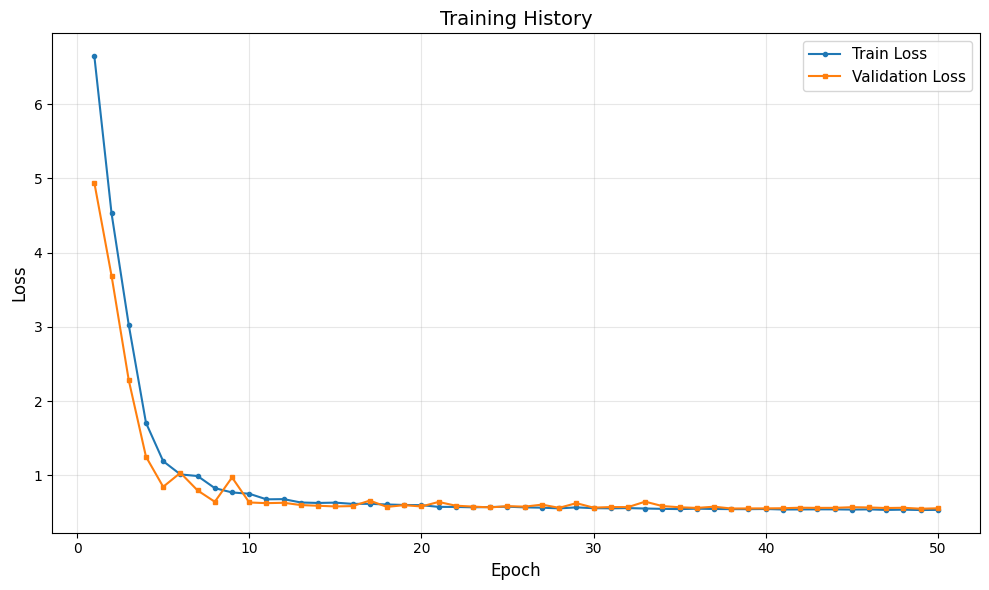

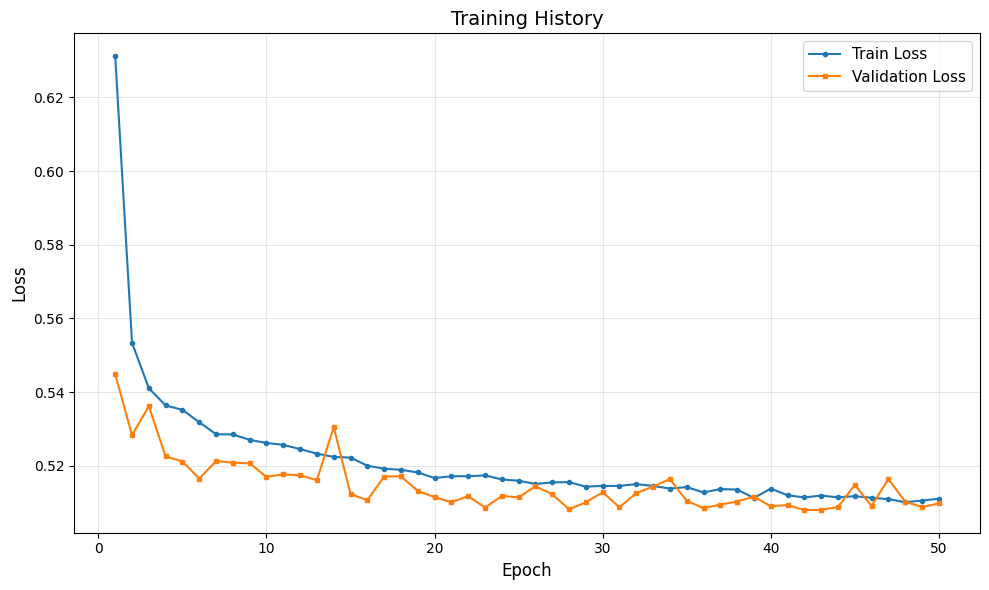

In [127]:
# Compare Training and Validation Loss Graphs
plotTrainingHistory(history_no_norm)
plotTrainingHistory(history_with_norm)

## Perbandingan Distribusi Bobot

AttributeError: 'list' object has no attribute 'weights'

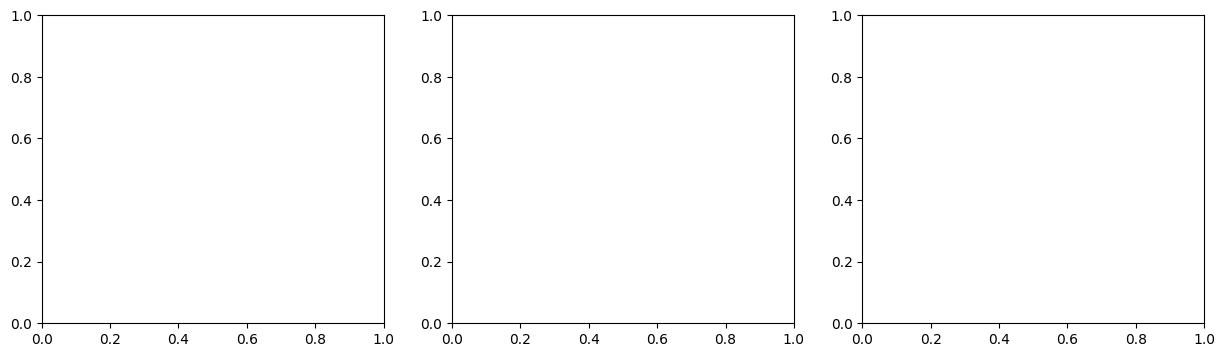

In [129]:
# Compare Weight Distributions
# gw lupa buat atur nama file sama pathnya jadinya yang model_no_norm langsung ke overwrite utk sekarang. udh kemaleman
plotWeightDistribution(model_no_norm.weights, [0,1,2])
plotWeightDistribution(model_with_norm.weights, [0,1,2])

## Perbandingan Distribusi Gradien Bobot

In [ ]:
# Compare Gradient Distributions
# Asumsikan grad sudah dihitung setelah backward terakhir
plotGradientDistribution(model_no_norm.grad_w, [0, 1, 2])
plotGradientDistribution(model_with_norm.grad_w, [0, 1, 2])